In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression



from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

import kagglehub
mlg_ulb_creditcardfraud_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')

print('Data source import complete.')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

data = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')
pd.options.display.max_columns = None

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Data source import complete.
/kaggle/input/creditcardfraud/creditcard.csv


In [7]:
data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
data['Class'].value_counts()


,count
Class,
0,284315
1,492


In [10]:
X = data.drop('Class', axis=1)
y = data['Class']


In [11]:
scaler = StandardScaler()

X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])


In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)


In [13]:
xf_train = X_train.values
xf_val   = X_val.values
xf_test  = X_test.values


In [14]:
dt = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

dt.fit(xf_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

rf.fit(xf_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=200,
                       random_state=42)

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }


In [24]:
results = []

results.append(evaluate_model("DT", dt, xf_test, y_test))
results.append(evaluate_model("RF", rf, xf_test, y_test))

final_results = pd.DataFrame(results)
final_results


,Model,Accuracy,Precision,Recall,F1,AUC
0,DT,0.997238,0.364198,0.797297,0.500000,0.898142
1,RF,0.999485,0.964286,0.729730,0.830769,0.954492


In [18]:
dt_pred = dt.predict(xf_test)

print(classification_report(y_test, dt_pred))
print("AUC:", roc_auc_score(y_test, dt.predict_proba(xf_test)[:, 1]))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.36      0.80      0.50        74

    accuracy                           1.00     42722
   macro avg       0.68      0.90      0.75     42722
weighted avg       1.00      1.00      1.00     42722

AUC: 0.898141670088772


In [19]:
rf_pred = rf.predict(xf_test)

print(classification_report(y_test, rf_pred))
print("AUC:", roc_auc_score(y_test, rf.predict_proba(xf_test)[:, 1]))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.96      0.73      0.83        74

    accuracy                           1.00     42722
   macro avg       0.98      0.86      0.92     42722
weighted avg       1.00      1.00      1.00     42722

AUC: 0.9544923370190673


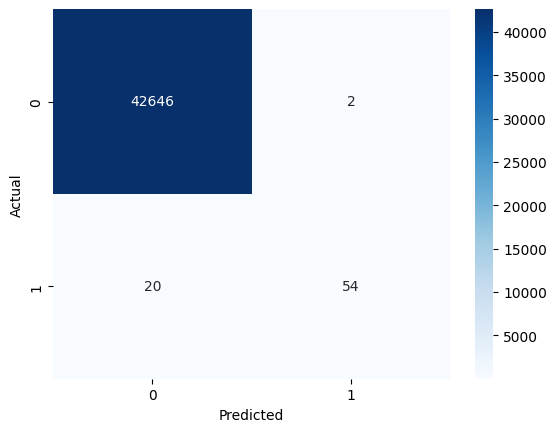

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [26]:
# Convert to NumPy arrays
X_train_np = X_train.values
X_val_np   = X_val.values
X_test_np  = X_test.values

# Reshape for Conv1D: (samples, features, channels)
X_train_cnn = X_train_np.reshape(X_train_np.shape[0], X_train_np.shape[1], 1)
X_val_cnn   = X_val_np.reshape(X_val_np.shape[0], X_val_np.shape[1], 1)
X_test_cnn  = X_test_np.reshape(X_test_np.shape[0], X_test_np.shape[1], 1)


In [29]:
cnn = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')  # Binary classification
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [31]:
history = cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=2048,
    validation_data=(X_val_cnn, y_val),
    verbose=1
)


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.8909 - loss: 0.2367 - val_accuracy: 0.9983 - val_loss: 0.0218
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9986 - loss: 0.0142 - val_accuracy: 0.9989 - val_loss: 0.0072
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9992 - loss: 0.0053 - val_accuracy: 0.9991 - val_loss: 0.0053
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9993 - loss: 0.0044 - val_accuracy: 0.9991 - val_loss: 0.0046
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9992 - val_loss: 0.0043
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9993 - loss: 0.0038 - val_accuracy: 0.9992 - val_loss: 0.0042
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9992 - val_loss: 0.0043
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.9995 - loss: 0.0030 - val_accuracy: 0.9992

In [32]:
cnn_prob = cnn.predict(X_test_cnn).ravel()
cnn_pred = (cnn_prob > 0.5).astype(int)

print(classification_report(y_test, cnn_pred))
print("CNN AUC:", roc_auc_score(y_test, cnn_prob))


1336/1336 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.92      0.76      0.83        74

    accuracy                           1.00     42722
   macro avg       0.96      0.88      0.91     42722
weighted avg       1.00      1.00      1.00     42722

CNN AUC: 0.9536507526096722


In [33]:
rf_prob = rf.predict_proba(xf_test)[:, 1]

comparison = pd.DataFrame({
    "Model": ["Random Forest", "CNN"],
    "AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, cnn_prob)
    ]
})

comparison


,Model,AUC
0,Random Forest,0.954492
1,CNN,0.953651


STACKING


In [34]:
# Decision Tree probabilities
dt_val_prob = dt.predict_proba(xf_val)[:, 1].reshape(-1, 1)

# Random Forest probabilities
rf_val_prob = rf.predict_proba(xf_val)[:, 1].reshape(-1, 1)

# CNN probabilities
cnn_val_prob = cnn.predict(X_val_cnn).reshape(-1, 1)


1336/1336 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [35]:
import numpy as np

X_stack_val = np.hstack([
    dt_val_prob,
    rf_val_prob,
    cnn_val_prob
])


In [36]:
stacking_model = LogisticRegression(max_iter=1000)
stacking_model.fit(X_stack_val, y_val)


LogisticRegression(max_iter=1000)

In [37]:
# Base model probabilities on test data
dt_test_prob = dt.predict_proba(xf_test)[:, 1].reshape(-1, 1)
rf_test_prob = rf.predict_proba(xf_test)[:, 1].reshape(-1, 1)
cnn_test_prob = cnn.predict(X_test_cnn).reshape(-1, 1)

# Stack them
X_stack_test = np.hstack([
    dt_test_prob,
    rf_test_prob,
    cnn_test_prob
])


1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [38]:
stack_pred = stacking_model.predict(X_stack_test)
stack_prob = stacking_model.predict_proba(X_stack_test)[:, 1]

print(classification_report(y_test, stack_pred))
print("Stacking AUC:", roc_auc_score(y_test, stack_prob))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.94      0.66      0.78        74

    accuracy                           1.00     42722
   macro avg       0.97      0.83      0.89     42722
weighted avg       1.00      1.00      1.00     42722

Stacking AUC: 0.9712860018149833


SAVING


In [40]:
import joblib

# Save classical ML models
joblib.dump(rf, "random_forest.pkl")
joblib.dump(dt, "decision_tree.pkl")
joblib.dump(stacking_model, "stacking_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save CNN
cnn.save("cnn_model.keras")
